<a href="https://colab.research.google.com/github/shubham-7745/PDS-Assignment/blob/main/practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Shubham Matsagar
Roll no - 05
Class - SY B AI&DS

Practical 8

Aim - Implement and analyze various methods of studying correlation and regression including
Karl Pearson’s coefficient and simple linear regression.

### 1. What is correlation? How is it different from regression?

**Correlation** measures the strength and direction of a linear relationship between two quantitative variables. It tells you *how* two variables move together. For example, a positive correlation means that as one variable increases, the other tends to increase as well.

**Regression**, on the other hand, describes the relationship between a dependent variable and one or more independent variables by fitting a line (or curve) to the data. It aims to model the relationship and, more importantly, to *predict* the value of the dependent variable based on the independent variable(s). While correlation simply indicates association, regression implies a predictive or explanatory relationship.

### 2. What is simple linear regression? Explain with suitable example.

**Simple linear regression** is a statistical method that models the relationship between two quantitative variables, one independent variable (predictor) and one dependent variable (response), using a straight line. The equation for a simple linear regression is typically given as:

`y = β₀ + β₁x + ε`

Where:
- `y` is the dependent variable.
- `x` is the independent variable.
- `β₀` (beta-naught) is the y-intercept, representing the expected value of `y` when `x` is 0.
- `β₁` (beta-one) is the slope, representing the change in `y` for a one-unit change in `x`.
- `ε` (epsilon) is the error term, accounting for the variability in `y` that cannot be explained by `x`.

**Example:**
Imagine you want to predict a student's final exam score (`y`) based on the number of hours they studied (`x`). A simple linear regression model might find a relationship like `Final_Score = 50 + 5 * Hours_Studied`. This means for every additional hour studied, the final score is predicted to increase by 5 points, and a student who studies 0 hours is predicted to score 50 points.

### 3. How do you calculate Pearson correlation in Python?

In Python, you can calculate the Pearson correlation coefficient using libraries like `pandas` or `scipy.stats`.

**Using pandas:**
If you have a pandas DataFrame, you can use the `.corr()` method:

```python
import pandas as pd

data = {'X': [1, 2, 3, 4, 5], 'Y': [2, 4, 5, 4, 5]}
df = pd.DataFrame(data)

pearson_corr = df['X'].corr(df['Y'])
# Or for the correlation matrix of the entire DataFrame:
# correlation_matrix = df.corr(method='pearson')
print(f"Pearson correlation: {pearson_corr}")
```

**Using scipy.stats:**

```python
from scipy.stats import pearsonr
import numpy as np

X = np.array([1, 2, 3, 4, 5])
Y = np.array([2, 4, 5, 4, 5])

pearson_corr, p_value = pearsonr(X, Y)
print(f"Pearson correlation: {pearson_corr}")
print(f"P-value: {p_value}")
```

### 4. What is multicollinearity? Does it affect simple regression?

**Multicollinearity** occurs in multiple regression when two or more independent variables in a model are highly correlated with each other. It means that one predictor variable can be linearly predicted from the others with a substantial degree of accuracy.

**Does it affect simple regression?**
No, multicollinearity **does not affect simple linear regression**. Simple linear regression involves only one independent variable, so there are no other independent variables for it to be correlated with. Multicollinearity is a concern *only* in multiple linear regression models, where multiple independent variables are used to predict a single dependent variable.

### 5. A dataset shows strong correlation but poor prediction accuracy. Why?

A dataset can show strong correlation but still have poor prediction accuracy for several reasons:

1.  **Non-linear Relationship:** Pearson correlation measures *linear* relationships. If the relationship between variables is strong but non-linear (e.g., quadratic, exponential), the Pearson correlation might still be high (if the non-linear trend is somewhat monotonic over the observed range), but a linear regression model (which assumes linearity) would perform poorly in prediction.

2.  **Outliers:** Outliers can significantly influence the correlation coefficient, potentially making it appear stronger than the true underlying relationship for the majority of the data points. If these outliers are not representative of the data you want to predict, the prediction accuracy will suffer.

3.  **Lack of Causation (Confounding Variables):** Correlation does not imply causation. Two variables might be highly correlated due to a third, unobserved confounding variable or simply by chance. If there's no causal link or if the correlation is due to a confounder not included in the model, the predictive power will be limited when applied to new data where the confounding factor might differ.

4.  **Small Sample Size:** In a small dataset, a strong correlation might appear by chance, but it may not generalize to the larger population, leading to poor out-of-sample prediction accuracy.

5.  **Overfitting:** If a complex model is built on a dataset with strong correlations, it might overfit the training data. This means it learns the noise and specific patterns of the training data too well, leading to excellent performance on the training set but poor generalization and prediction accuracy on new, unseen data.

6.  **Other Factors at Play:** Even if two variables are strongly correlated, the dependent variable might also be influenced by many other factors not included in the model. If these other factors have significant impact, a model relying only on the correlated variable will have limited predictive power.

 Karl Pearson’s Correlation Coefficient (manual): 1.0000
 Verified using scipy: 1.0000


Regression Equation: Marks = 5.21 * Hours + 30.33
 Mean Squared Error (MSE): 3.68
 R² Score: 0.9839


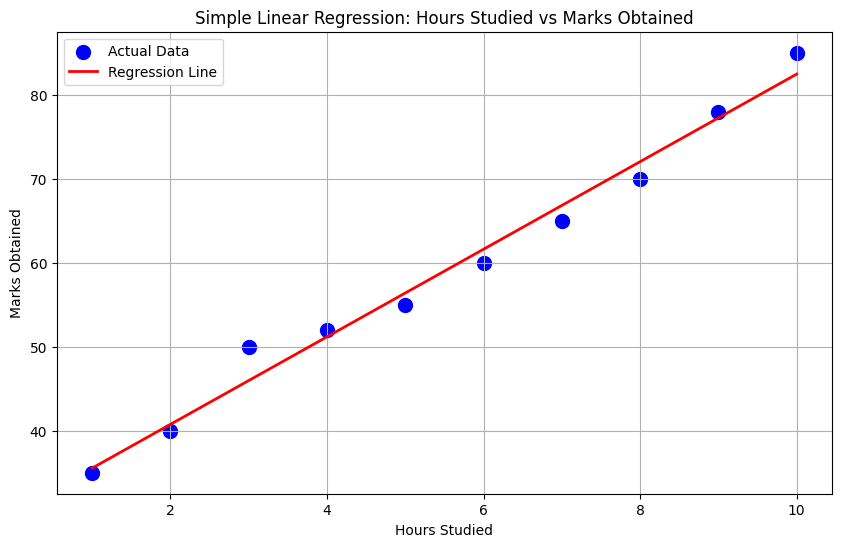

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Karl Pearson's Correlation Coefficient ---
# Sample data
X_corr = [10, 20, 30, 40, 50]
Y_corr = [15, 25, 35, 45, 55]

# Manual implementation of Pearson correlation
def pearson_coefficient(x, y):
    n = len(x)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    numerator = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
    denominator = (sum((x[i] - mean_x)**2 for i in range(n)) * sum((y[i] - mean_y)**2 for i in range(n)))**0.5
    return numerator / denominator

# Calculate Karl Pearson's correlation coefficient
r = pearson_coefficient(X_corr, Y_corr)
print(f" Karl Pearson’s Correlation Coefficient (manual): {r:.4f}")

# Verification using scipy
r_scipy, _ = pearsonr(X_corr, Y_corr)
print(f" Verified using scipy: {r_scipy:.4f}")

print("\n" + "="*50 + "\n") # Separator for clarity

# --- Simple Linear Regression ---
# Step 1: Sample Data
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marks_Obtained': [35, 40, 50, 52, 55, 60, 65, 70, 78, 85]
}
df = pd.DataFrame(data)

# Step 2: Split data into input (X) and output (y)
X_reg = df[['Hours_Studied']] # Independent variable
y_reg = df['Marks_Obtained'] # Dependent variable

# Step 3: Train the Linear Regression Model
model = LinearRegression()
model.fit(X_reg, y_reg)

# Step 4: Get model parameters
slope = model.coef_[0]
intercept = model.intercept_
print(f"Regression Equation: Marks = {slope:.2f} * Hours + {intercept:.2f}")

# Step 5: Predict values
y_pred = model.predict(X_reg)

# Step 6: Evaluate the Model
mse = mean_squared_error(y_reg, y_pred)
r2 = r2_score(y_reg, y_pred)
print(f" Mean Squared Error (MSE): {mse:.2f}")
print(f" R² Score: {r2:.4f}")

# Step 7: Visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='blue', label='Actual Data', s=100)
plt.plot(X_reg, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Hours Studied vs Marks Obtained')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Obtained')
plt.grid(True)
plt.legend()
plt.show()

Conclusion:
Correlation measures the strength of a relationship, while regression is used to
predict outcomes. Simple linear regression models a linear link between two variables. Tools
like NumPy and Pandas help compute the Pearson correlation coefficient easily. A high
correlation doesn’t always mean good prediction due to factors like noise or nonlinearity.